####  B Vidakovic Quantum Framework for Wavelet Shrinkage 
## Example 6

# Blocks Denoising (N = 1024, SNR = 7) — Haar Wavelet with Quantum-Inspired Shrinkage

This notebook demonstrates denoising of the Donoho–Johnstone **Blocks** signal using the orthogonal **Haar (db1)** wavelet and two quantum-inspired shrinkage methods alongside a classical baseline:

- **Classical soft-thresholding**
- **K0 postselected diagonal attenuation** on amplitudes (quantum-inspired, non-CPTP)
- **CPTP ancilla-sink** attenuation via an **analytical density-matrix** update

All approaches run at $N=1024$ with linear SNR $=7$. Figures compare reconstructions and print SNRs.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
try:
    import pywt
except Exception as e:
    raise RuntimeError("PyWavelets (pywt) is required. Install via: pip install pywavelets") from e


## 1) Generate the Blocks signal (Donoho–Johnstone)

In [3]:
N = 1024
t = (np.arange(1, N+1) / N).astype(float)
pos = np.array([0.10, 0.13, 0.15, 0.23, 0.25, 0.40, 0.44, 0.65, 0.76, 0.78, 0.81])
hgt = np.array([ 4.0, -5.0,  3.0, -4.0,  5.0, -4.2,  2.1,  4.3, -3.1,  2.1, -4.2])
x_clean = np.zeros_like(t)
for p, h in zip(pos, hgt):
    x_clean += (1.0 + np.sign(t - p)) * (h / 2.0)
x_clean -= x_clean.mean()


## 2) Add Gaussian noise (linear SNR = 7)

In [4]:
SNR_linear = 7.0
sig_power = np.mean(x_clean**2)
sigma_noise = np.sqrt(sig_power / SNR_linear)
rng = np.random.default_rng(42)
y_noisy = x_clean + rng.normal(0.0, sigma_noise, size=N)

def snr_db(clean, est):
    num = np.sum(clean**2)
    den = np.sum((clean - est)**2) + 1e-15
    return 10*np.log10(num/den)

print("Noisy SNR (dB):", round(snr_db(x_clean, y_noisy), 2))


Noisy SNR (dB): 8.59


## 3) Haar DWT and noise estimate from finest details

In [5]:
wavelet = pywt.Wavelet('haar')  # or 'db1'
L = pywt.dwt_max_level(N, wavelet.dec_len)
coeffs = pywt.wavedec(y_noisy, wavelet=wavelet, level=L, mode='periodization')
w_array, w_slices = pywt.coeffs_to_array(coeffs)

# MAD on cD1
cD1 = coeffs[-1]
sigma_encoded = np.median(np.abs(cD1 - np.median(cD1))) / 0.6745
tau = np.sqrt(2*np.log(N)) * sigma_encoded
print("sigma_encoded:", round(sigma_encoded, 4), " tau:", round(tau, 4))


sigma_encoded: 0.6545  tau: 2.437


## 4) Build shrinkage profile $a_i$ and amplitude state

In [6]:
w = w_array.astype(float)
norm_w = np.linalg.norm(w) + 1e-15
psi = w / norm_w
abs_w = np.abs(w) + 1e-15
a = np.maximum(0.0, 1.0 - tau/abs_w)
print("Mean a_i:", float(a.mean()))


Mean a_i: 0.02236947210216953


## 5) Method A — K0 postselected attenuation on amplitudes (non-CPTP)

In [7]:
K0_diag = np.sqrt(a)
psi_post = K0_diag * psi
psi_post /= (np.linalg.norm(psi_post) + 1e-15)
w_k0 = psi_post * norm_w


## 6) Method B — CPTP ancilla-sink attenuation (analytical density-matrix update)

In [8]:
# Ancilla=0 diagonal probabilities before attenuation
p = (np.abs(psi)**2)
# After CPTP: p'_i = a_i * p_i
p_prime = a * p
amp_mag = np.sqrt(p_prime)
w_cptp = np.sign(w) * amp_mag * norm_w  # reuse signs; preserve phases if tracked


## 7) Classical soft-threshold baseline

In [9]:
w_soft = np.sign(w) * np.maximum(abs_w - tau, 0.0)


## 8) Inverse DWT and SNRs

In [10]:
x_k0 = pywt.waverec(pywt.array_to_coeffs(w_k0,  w_slices, output_format='wavedec'),
                    wavelet=wavelet, mode='periodization')[:N]
x_cptp = pywt.waverec(pywt.array_to_coeffs(w_cptp, w_slices, output_format='wavedec'),
                      wavelet=wavelet, mode='periodization')[:N]
x_soft = pywt.waverec(pywt.array_to_coeffs(w_soft, w_slices, output_format='wavedec'),
                      wavelet=wavelet, mode='periodization')[:N]

snr_noisy = snr_db(x_clean, y_noisy)
snr_soft  = snr_db(x_clean, x_soft)
snr_k0    = snr_db(x_clean, x_k0)
snr_cptp  = snr_db(x_clean, x_cptp)

print("Summary SNRs (dB):")
print("  Noisy:          {:.2f}".format(snr_noisy))
print("  Classical soft: {:.2f}".format(snr_soft))
print("  K0-postselect:  {:.2f}".format(snr_k0))
print("  CPTP ancilla:   {:.2f}".format(snr_cptp))


Summary SNRs (dB):
  Noisy:          8.59
  Classical soft: 10.97
  K0-postselect:  13.90
  CPTP ancilla:   13.88


## 9) Plots

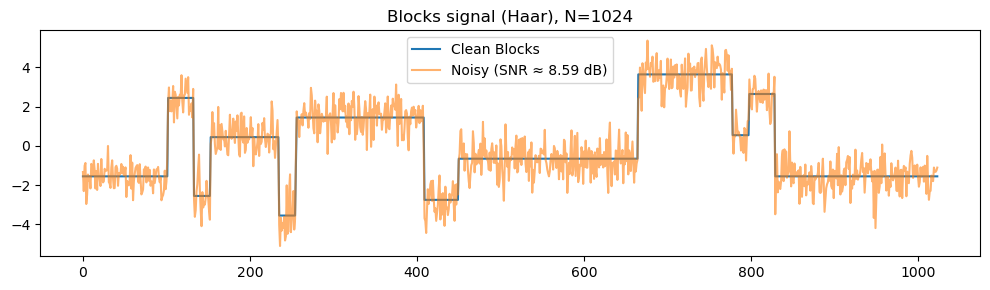

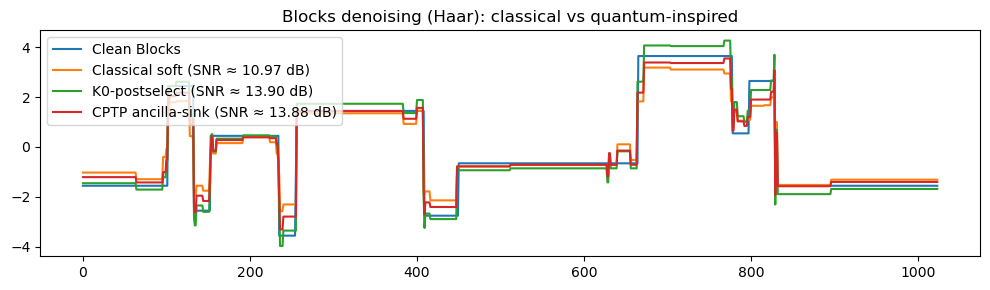

In [11]:
plt.figure(figsize=(10, 3.0))
plt.plot(x_clean, label='Clean Blocks')
plt.plot(y_noisy, label=f'Noisy (SNR ≈ {snr_noisy:.2f} dB)', alpha=0.6)
plt.legend(); plt.title('Blocks signal (Haar), N=1024'); plt.tight_layout(); 
plt.savefig("ex06blocks1.png", dpi=300, bbox_inches="tight")
plt.savefig("ex06blocks1.pdf", dpi=300, bbox_inches="tight")
plt.show()  # <- show only after saving
 

plt.figure(figsize=(10, 3.0))
plt.plot(x_clean, label='Clean Blocks')
plt.plot(x_soft, label=f'Classical soft (SNR ≈ {snr_soft:.2f} dB)')
plt.plot(x_k0, label=f'K0-postselect (SNR ≈ {snr_k0:.2f} dB)')
plt.plot(x_cptp, label=f'CPTP ancilla-sink (SNR ≈ {snr_cptp:.2f} dB)')
plt.legend(); plt.title('Blocks denoising (Haar): classical vs quantum-inspired'); plt.tight_layout();  
plt.savefig("ex06blocks2.png", dpi=300, bbox_inches="tight")
plt.savefig("ex06blocks2.pdf", dpi=300, bbox_inches="tight")
plt.show()  # <- show only after saving


## 10) (Optional) 8×8 Haar unitary check

In [12]:
import numpy as np
def haar_level_mats(n):
    half = n // 2
    A = np.zeros((half, n), dtype=float)
    D = np.zeros((half, n), dtype=float)
    inv = 1.0 / np.sqrt(2.0)
    for k in range(half):
        i0, i1 = 2*k, 2*k+1
        A[k, i0] = inv; A[k, i1] = inv
        D[k, i0] = inv; D[k, i1] = -inv
    return A, D

def dwt_haar_2level_8():
    W = np.zeros((8, 8), dtype=float)
    I = np.eye(8, dtype=float)
    for i in range(8):
        s = I[:, i]
        A1, D1 = haar_level_mats(8)
        a1 = A1 @ s
        d1 = D1 @ s
        A2, D2 = haar_level_mats(4)
        a2 = A2 @ a1
        d2 = D2 @ a1
        W[:, i] = np.concatenate([a2, d2, d1])
    return W

W8 = dwt_haar_2level_8()
orth_err = np.linalg.norm(W8.T @ W8 - np.eye(8))
print("8x8 Haar unitary orthogonality error:", orth_err)


8x8 Haar unitary orthogonality error: 1.01479998476398e-15
